# Summary figure: what each analysis is sensitive to

A 6 x 3 layout for the argument of `region_space.ipynb`, self-contained: it imports the
same generator and reads the same caches, and computes nothing that notebook does not.

| | columns 1-2 | columns 3-5 | column 6 |
|---|---|---|---|
| **row 1** | empty, for the schematic | three example regions as clouds of neurons in tuning-shape space | the design sweep, scored in neuron space |
| **row 2** | " | the same three as population manifolds | the design sweep, scored in region space |

The three examples differ from the first in exactly one parameter each: the middle changes
$\psi$ at fixed $a$ (the geometry moves, the clustering does not), the right changes $a$ at
fixed $\psi$ (clusters appear, the geometry does not).

The two maps in column 6 come from `grid_space.ipynb`, which sweeps within-region
clustering against across-region clustering and scores each cell by both analyses. They are
the general statement of what the three examples show one case of.

In [1]:
from pathlib import Path

from shapemetrics import paths
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA

R = paths.figure_code("Figure1").region_space

OUT = paths.set_figure("Figure1")
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# Everything at twice the scale of region_full.pdf: panels from 1.95 in to 3.90,
# and the type scale doubled with them, so the block is a straight 2x version of
# the house style rather than large panels carrying small text.
SCALE = 2
FS_HEAD, FS_TITLE, FS_LABEL = 11 * SCALE, 9 * SCALE, 8.5 * SCALE
PC2 = 1.95 * SCALE

## The three example regions

Generated directly rather than drawn from a scenario, so each panel varies one knob. Seed
12 is not arbitrary: the $a$ contrast is sampling noise by construction (its distance
equals the floor of drawing the same region twice), and that floor is wide enough that an
unlucky draw makes the third manifold visibly miss the reference. At seed 12 the $\psi$
contrast is 18.3 against 0.62 for $a$, a ratio of 29.6. The seed is tied to the panel
order, since `R.simulate` draws regions in sequence from one stream.

In [2]:
ex_a, ex_psi = [0.0, 0.0, 0.95], [-R.PSI, np.radians(22.5), -R.PSI]
NEX = len(ex_a)
ETIT = ["no clusters\n$a$ = 0, $\\psi$ = $-45^\\circ$",
        "different geometry\n$a$ = 0, $\\psi$ = $+22.5^\\circ$",
        "two clusters\n$a$ = 0.95, $\\psi$ = $-45^\\circ$"]
Xe, rege = R.simulate(ex_a, ex_psi, seed=12)


def shape_coords(X):
    """Each neuron's (skew, width), recovered by projecting on the modes it was
    built from.  Mode 2 rises with the von Mises concentration, i.e. with
    NARROWER tuning, so it is negated to give a true width axis."""
    W = (X - R.MEAN) @ R.MODES.T / R.SCALE
    return np.c_[W[:, 0], -W[:, 1]]


# one plane fitted to the three regions pooled, so the panels share axes; a
# per-region PCA would give each its own rotation and the psi difference between
# the first two would vanish into PC 1
We = PCA(2).fit_transform(Xe)
_A = np.c_[We, np.ones(len(We))]
_B = np.linalg.lstsq(_A, shape_coords(Xe), rcond=None)[0][:2]
SHAPE_DIRS = _B / np.linalg.norm(_B, axis=0)          # columns: skew, width

cl = [We[rege == i] - We[rege == i].mean(0) for i in range(NEX)]
elim = 1.05 * np.percentile(np.abs(np.concatenate(cl)), 99.5)
print(f"{len(Xe)} neurons over {NEX} regions, {Xe.shape[1]} theta bins")

300 neurons over 3 regions, 120 theta bins


## The manifolds those clouds produce

PCA over the neuron dimension, so the points are the conditions. Each is centred, scaled to
unit Frobenius norm, and rotated onto the first region by the orthogonal transform the
shape metric optimises over, so the grey reference is one fixed curve in all three panels
and "does the grey match" *is* the Procrustes comparison.

PC 1 carries about 97% of a manifold's variance and PC 2 about 2%, so equal limits would
draw it as a sliver. Each axis gets its own limit, the same stretch is applied to every
panel, and the alignment was computed in the true isotropic space, so grey against colour
stays exact even though the display is not metric.

In [3]:
def align_to(A, B):
    """Rotate/reflect B onto A: the transform the shape metric optimises over."""
    U, _, Vt = np.linalg.svd(B.T @ A)
    return B @ (U @ Vt)


MAN = []
for _i in range(NEX):
    _m = PCA(2).fit_transform(Xe[rege == _i].T)
    _m = _m - _m.mean(0)
    MAN.append(_m / np.linalg.norm(_m))
MREF = MAN[0]
MAN_AL = [align_to(MREF, m) for m in MAN]
_allm = np.concatenate(MAN_AL + [MREF])
mlx = 1.06 * np.abs(_allm[:, 0]).max()
mly = 1.06 * np.abs(_allm[:, 1]).max()
print(f"manifold variance on PC1/PC2: "
      f"{PCA(2).fit(Xe[rege == 0].T).explained_variance_ratio_.round(3)}")

manifold variance on PC1/PC2: [0.968 0.03 ]


## The figure

canvas 23.40 x 9.17 in at the figure-1 type scale (22/18/17.0 pt)


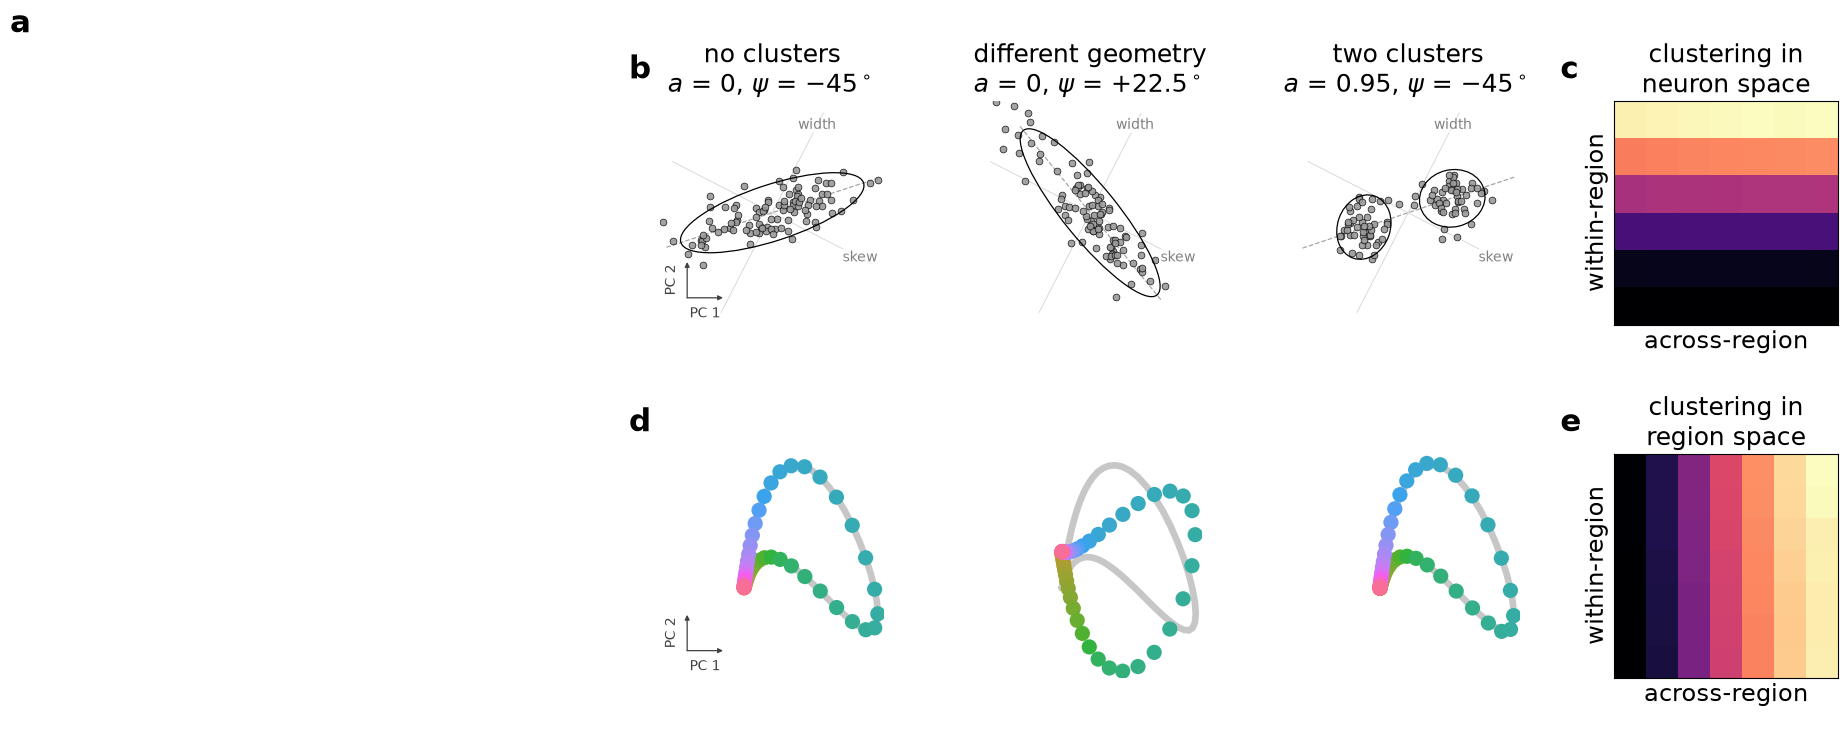

In [4]:
def gauss_ellipse(ax, P, nsd=2.0):
    w, V = np.linalg.eigh(np.cov(P, rowvar=False))
    ax.add_patch(Ellipse(P.mean(0), 2 * nsd * np.sqrt(w[-1]), 2 * nsd * np.sqrt(w[-2]),
                         angle=np.degrees(np.arctan2(V[1, -1], V[0, -1])),
                         fill=False, lw=0.9, ec="black", zorder=3))


def pc_arrows(ax, xl="PC 1", yl="PC 2", x0=0.12, y0=0.12, L=0.16, fs=5 * SCALE):
    """The PC axes carry no units, so a pair of arrows replaces the labels."""
    for dx, dy in ((L, 0), (0, L)):
        ax.annotate("", xy=(x0 + dx, y0 + dy), xytext=(x0, y0),
                    xycoords="axes fraction", textcoords="axes fraction",
                    annotation_clip=False, zorder=6,
                    arrowprops=dict(arrowstyle="-|>", lw=0.9, color="0.25",
                                    shrinkA=0, shrinkB=0, mutation_scale=7))
    ax.text(x0 + L / 2, y0 - 0.04, xl, transform=ax.transAxes, fontsize=fs,
            color="0.25", ha="center", va="top", zorder=6)
    ax.text(x0 - 0.04, y0 + L / 2, yl, transform=ax.transAxes, fontsize=fs,
            color="0.25", ha="right", va="center", rotation=90, zorder=6)


def _letter(ax, s, dx=-0.14, dy=1.10):
    ax.text(dx, dy, s, transform=ax.transAxes, fontweight="bold", fontsize=FS_HEAD)


fig = plt.figure(figsize=(6 * PC2, 2.35 * PC2))
# row 2 carries no titles and row 1 no x labels, so the two rows can sit
# flush against one another
gs = fig.add_gridspec(2, 6, wspace=.42, hspace=.0)

# columns 1-2: a 3 x 2 block left empty for the schematic.  The axes are drawn
# and switched off rather than omitted, so the spacing is honest.
_left = gs[:, :2].subgridspec(3, 2, wspace=.25, hspace=.25)
for _r in range(3):
    for _c in range(2):
        _e = fig.add_subplot(_left[_r, _c])
        _e.axis("off")
        if _r == 0 and _c == 0:
            _letter(_e, "a", dx=-0.06, dy=1.02)

# row 1, columns 3-5: the regions as clouds of neurons
for n in range(NEX):
    ax = fig.add_subplot(gs[0, 2 + n])
    u = np.linalg.eigh(np.cov(cl[n], rowvar=False))[1][:, -1]
    for _j, _nm in enumerate(("skew", "width")):
        _d = SHAPE_DIRS[:, _j]
        ax.plot([-elim * _d[0], elim * _d[0]], [-elim * _d[1], elim * _d[1]],
                color="0.85", lw=0.7, zorder=0)
        ax.text(0.88 * elim * _d[0], 0.88 * elim * _d[1], _nm, fontsize=5 * SCALE,
                color="0.5", ha="center", va="center", zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7,
                          boxstyle="square,pad=0.08"))
    ax.plot([-elim * u[0], elim * u[0]], [-elim * u[1], elim * u[1]],
            color="0.65", lw=0.9, ls="--", zorder=1)
    ax.scatter(cl[n][:, 0], cl[n][:, 1], s=6 * SCALE**2, facecolor="0.6", edgecolor="black",
               linewidths=0.25 * SCALE, alpha=0.9, zorder=2)
    if n == 2:                                  # a = 0.95: two lobes, fitted apart
        proj = cl[n] @ u
        for m in (proj < 0, proj >= 0):
            gauss_ellipse(ax, cl[n][m])
    else:
        gauss_ellipse(ax, cl[n])
    ax.set(xlim=(-elim, elim), ylim=(-elim, elim), xticks=[], yticks=[])
    ax.set_title(ETIT[n], fontsize=FS_TITLE, pad=4)
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)
    if n == 0:
        _letter(ax, "b")
        pc_arrows(ax)

# row 2, columns 3-5: the same three as population manifolds
for n in range(NEX):
    ax = fig.add_subplot(gs[1, 2 + n])
    ax.plot(MREF[:, 0], MREF[:, 1], color="0.78", lw=2.4 * SCALE, zorder=0)
    mx, my = MAN_AL[n][::2].T
    ax.scatter(mx, my, lw=0, s=30 * SCALE**2, zorder=2, c=np.linspace(0, 1, len(mx)),
               cmap=ListedColormap(sns.color_palette("husl", len(mx))))
    ax.set(xlim=(-mlx, mlx), ylim=(-mly, mly), xticks=[], yticks=[])
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)
    if n == 0:
        _letter(ax, "d")
        pc_arrows(ax)

# column 6: the two-dimensional design sweep, scored both ways.  Computed in
# grid_space.ipynb (147 cell-seeds, ~20 min); the neuron-space map drops its
# bottom row (a = 0) to match that notebook's figure.
# At 2000 neurons per region rather than the 150 of the first sweep.  The
# residual dependence of the region-space map on within-region clustering is
# finite-sampling noise in the estimated second moment, and it falls away as
# neurons are added: rho_within 0.33 -> 0.17 -> 0.13 at N = 150, 600, 2000,
# while rho_across rises 0.91 -> 0.98 -> 0.99.  Both panels come from the same
# N so the two maps are comparable.
_hm_a = OUT / "grid_2d_n2000_neurons.npz"
_hm_b = OUT / "grid_2d_n2000_regions.npz"
if _hm_a.exists() and _hm_b.exists():
    _ZA = np.load(_hm_a)["ZA"].mean(2)[1:]     # drops the a = 0 row, as before
    _ZB = np.load(_hm_b)["ZB"].mean(2)
    for _M, _t, _row, _let in ((_ZA, "clustering in\nneuron space", 0, "c"),
                               (_ZB, "clustering in\nregion space", 1, "e")):
        ax = fig.add_subplot(gs[_row, 5])
        ax.imshow(_M, origin="lower", cmap="magma", aspect="auto",
                  vmin=_M.min(), vmax=_M.max())
        ax.set_box_aspect(1)
        ax.set(xticks=[], yticks=[])
        ax.set_ylabel("within-region", fontsize=FS_LABEL)
        ax.set_xlabel("across-region", fontsize=FS_LABEL)
        ax.set_title(_t, fontsize=FS_TITLE, pad=4)
        _letter(ax, _let, dx=-0.24)
else:
    print("2000-neuron grids not found -- run the N = 2000 sweep first")

# Saved at the declared figsize, NOT bbox_inches="tight".  The reserved block in
# columns 1-2 holds no artists, so a tight bounding box crops it away: the same
# figure came out 9.34 in wide instead of 11.70, losing the space the schematic
# goes in, and the saved width would shift again whenever a label is added.
# A fixed canvas is what makes the file paste at 100% into the assembled figure.
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_summary_6x3.{e}", dpi=300 if e == "png" else None)
print(f"canvas {fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in "
      f"at the figure-1 type scale ({FS_HEAD}/{FS_TITLE}/{FS_LABEL} pt)")
plt.show()

## Reading it

**b.** Three regions, each a cloud of 100 neurons in the plane of tuning shapes. The middle
differs from the left only in $\psi$, the right only in $a$.

**d.** The same three as the population manifolds a shape metric actually compares, each
rotated onto the first. The middle misses the grey reference and the right lies on it: the
region with two clear cell types has the same geometry as the region with none, and the
region with no cell types at all has a different one.

**c, e.** The general case. Sweeping within-region clustering against across-region
clustering, the neuron-space score varies along one axis and is flat along the other, while
the region-space score does the reverse. The two analyses are sensitive to different things,
and neither substitutes for the other.